# Eval exp

In [ ]:
#@title 1 Config (edit only here)
import os
from datetime import datetime

# Reproducibility
SEED = 123

# Local LeRobot v3 dataset dir (used for normalization stats)
DATASET_DIR = "/content/k_dataset"

# --- HF model selection (checkpoint-style repo) ---
MODEL_REPO = "mimirmimir/k_smolvla"
CHECKPOINT_STEP = "040000"

# Path finale usato da LeRobot (punta alla cartella con config.json e pesi)
MODEL_ID = f"{MODEL_REPO}/checkpoints/{CHECKPOINT_STEP}/pretrained_model"

# Common eval params
DEVICE = "cuda"          # "cuda" or "cpu"
MAX_STEPS = 200          # per episode
NUM_TRIALS = 3           # per task
NUM_VIDEOS_TO_SAVE = 3   # per task (first N trials will save video)
CONTROL_MODE = "pd_joint_pos"
OBS_MODE = "rgb"
RENDER_MODE = "rgb_array"
VIDEO_FPS = 20

# --- ROBUSTNESS SETTINGS (Nuovi Parametri) ---
NOISE_STD = 0.075          # Rumore Gaussiano (es. 0.05). Metti 0.0 per disattivare.
OCCLUSION_SIZE = 0       # Dimensione quadrato nero (es. 50). Metti 0 per disattivare.

# Where to save everything
EPISODES_ROOT = "/content/lerobot/episodes"
os.makedirs(EPISODES_ROOT, exist_ok=True)

# Task map
TASK_MAP = {
    "pickcube": {
        "task_id": "pickcube",
        "env_id": "PickCube-v1",
        "task_prompt": "Pick up the red cube and bring it to the green goal",
    },
    "stackcube": {
        "task_id": "stackcube",
        "env_id": "StackCube-v1",
        "task_prompt": "Pick up the red cube and stack it on top of the green cube",
    },
    "pushcube": {
        "task_id": "pushcube",
        "env_id": "PushCube-v1",
        "task_prompt": "Push the blue cube towards the target",
    },
    "peg_insert": {
        "task_id": "peg_insert",
        "env_id": "PegInsertionSide-v1",
        "task_prompt": "Pick up the peg and insert it into the hole",
    },
}

# Choose which tasks to run
TASKS_TO_RUN = ["pickcube"] #["pickcube", "stackcube", "pushcube", "peg_insert"]

# Run identifier
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
print("RUN_ID:", RUN_ID)
print("MODEL_ID:", MODEL_ID)
if NOISE_STD > 0: print(f"⚠️ NOISE APPLIED: std={NOISE_STD}")
if OCCLUSION_SIZE > 0: print(f"⚠️ OCCLUSION APPLIED: size={OCCLUSION_SIZE}px")

RUN_ID: 20260218_130630
MODEL_ID: mimirmimir/k_smolvla/checkpoints/040000/pretrained_model
⚠️ NOISE APPLIED: std=0.075


In [ ]:
#@title 2 Imports + seeds + load policy + processors
import json
import random
import numpy as np
import torch

import mani_skill.envs
import gymnasium as gym
from mani_skill.utils.wrappers import RecordEpisode

from huggingface_hub import snapshot_download
from lerobot.datasets.lerobot_dataset import LeRobotDatasetMetadata
from lerobot.policies.smolvla.modeling_smolvla import SmolVLAPolicy
from lerobot.policies.factory import make_pre_post_processors

def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # make cudnn deterministic-ish (note: may reduce perf)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_all_seeds(SEED)

device = torch.device(DEVICE if (DEVICE == "cuda" and torch.cuda.is_available()) else "cpu")
print("Using device:", device)

# Dataset metadata (stats for normalization)
ds_meta = LeRobotDatasetMetadata(DATASET_DIR)

# Resolve HF "namespace/repo/.../subfolder" into a local folder path
model_path = MODEL_ID
if isinstance(MODEL_ID, str) and MODEL_ID.count("/") > 1 and (not os.path.isdir(MODEL_ID)):
    parts = MODEL_ID.split("/")
    repo_id = "/".join(parts[:2])
    subpath = "/".join(parts[2:])
    snap_dir = snapshot_download(repo_id=repo_id, repo_type="model")
    model_path = os.path.join(snap_dir, subpath)

# Load fine-tuned policy
policy = SmolVLAPolicy.from_pretrained(model_path)
policy.to(device)
policy.eval()

# Build LeRobot pre/post processors (use dataset stats)
preprocessor, postprocessor = make_pre_post_processors(
    policy_cfg=policy.config,
    dataset_stats=ds_meta.stats,
    preprocessor_overrides={
        "device_processor": {"device": str(device)},
    },
)

print("Loaded policy + processors.")
print("Resolved model_path:", model_path)


Using device: cuda


Fetching 97 files:   0%|          | 0/97 [00:00<?, ?it/s]

Loading  HuggingFaceTB/SmolVLM2-500M-Video-Instruct weights ...
Reducing the number of VLM layers to 16 ...
Loading weights from local directory
Loaded policy + processors.
Resolved model_path: /root/.cache/huggingface/hub/models--mimirmimir--k_smolvla/snapshots/c89c0f21a9d815f5b1914ea7859ae9f6af920c44/checkpoints/040000/pretrained_model


In [ ]:
#@title 3 Helpers (env creation, obs->dict, rollout, stats saving)
import os
from pathlib import Path
from typing import Dict, Any, Tuple, List
import numpy as np
import torch
import torch.nn.functional as F

def make_env(env_id: str, *, save_video: bool, output_dir: str) -> gym.Env:
    """
    Creates a ManiSkill env + optional RecordEpisode wrapper.
    """
    env = gym.make(
        env_id,
        obs_mode=OBS_MODE,
        control_mode=CONTROL_MODE,
        render_mode=RENDER_MODE,
        max_episode_steps=MAX_STEPS,
    )

    if save_video:
        os.makedirs(output_dir, exist_ok=True)
        env = RecordEpisode(
            env,
            output_dir=output_dir,
            save_video=True,
            save_trajectory=False,
            max_steps_per_video=MAX_STEPS,
            video_fps=VIDEO_FPS,
        )
    return env

def build_policy_observation_dict(
    obs: Dict[str, Any],
    *,
    task_prompt: str,
) -> Dict[str, Any]:
    # State: full qpos (9 DoF) -> (1, 9)
    qpos = obs["agent"]["qpos"][0].float()
    state = qpos.unsqueeze(0).to(device)

    # Image: base_camera rgb -> (1, 3, H, W) float [0,1]
    rgb = obs["sensor_data"]["base_camera"]["rgb"][0]  # (H, W, 3)
    img = rgb.permute(2, 0, 1).float() / 255.0         # (3, H, W)

    # --- A. INIEZIONE RUMORE (Gaussian Noise) ---
    if 'NOISE_STD' in globals() and NOISE_STD > 0:
        noise = torch.randn_like(img) * NOISE_STD
        img = img + noise
        img = torch.clamp(img, 0.0, 1.0) # Fondamentale clampare tra 0 e 1

    # --- B. INIEZIONE OCCLUSIONE (Random Patch nera) ---
    if 'OCCLUSION_SIZE' in globals() and OCCLUSION_SIZE > 0:
        _, h, w = img.shape
        # Assicuriamoci che il patch stia nell'immagine
        max_y = max(0, h - OCCLUSION_SIZE)
        max_x = max(0, w - OCCLUSION_SIZE)

        top = torch.randint(0, max_y + 1, (1,)).item()
        left = torch.randint(0, max_x + 1, (1,)).item()

        # Applica il patch nero (tutti i canali a 0)
        img[:, top:top+OCCLUSION_SIZE, left:left+OCCLUSION_SIZE] = 0.0

    img = img.unsqueeze(0).to(device)                  # (1, 3, H, W)

    return {
        "observation.state": state,
        "observation.images.camera1": img,
        "task": [task_prompt],
    }


def clip_action_to_space(action: np.ndarray, action_space) -> np.ndarray:
    """
    Env-side postprocessing: clip to bounds
    """
    a = action.astype(np.float32, copy=False)
    if a.ndim != 1:
        a = a.reshape(-1)
    a = a[: action_space.shape[0]]
    return np.clip(a, action_space.low, action_space.high).astype(np.float32)

@torch.no_grad()
def run_one_episode(
    env: gym.Env,
    *,
    task_prompt: str,
    max_steps: int,
    seed: int,
) -> Dict[str, Any]:
    """
    Single-env rollout
    """
    policy.reset()
    obs, info = env.reset(seed=seed)

    rewards: List[float] = []
    successes: List[bool] = []
    terminateds: List[bool] = []
    truncateds: List[bool] = []

    # Per salvare l'immagine di debug (ciò che vede la policy)
    first_frame_vis = None

    for t in range(max_steps):
        # Construct dict (qui viene applicato rumore/occlusione)
        obs_dict = build_policy_observation_dict(obs, task_prompt=task_prompt)

        # --- CATTURA VISUALE ---
        if t == 0:
            # Estraiamo l'immagine dal tensore (già rumoroso/occluso)
            img_tensor = obs_dict["observation.images.camera1"][0] # (3, H, W)
            # Converti per visualizzazione: (H, W, 3) -> cpu -> numpy uint8
            img_vis = img_tensor.permute(1, 2, 0).cpu().clamp(0, 1).numpy()
            first_frame_vis = (img_vis * 255).astype(np.uint8)
        # -----------------------

        # LeRobot pre/postprocessors
        batch = preprocessor(obs_dict)

        action_out = policy.select_action(batch)
        if action_out.ndim == 3:
            action_out = action_out[:, 0, :]

        action_out = postprocessor(action_out)

        # Convert to env action
        a = action_out[0].detach().cpu().float().numpy()
        env_action = clip_action_to_space(a, env.action_space)

        obs, reward, terminated, truncated, info = env.step(env_action)

        rewards.append(float(reward))
        success = bool(info.get("success", False))
        successes.append(success)
        terminateds.append(bool(terminated))
        truncateds.append(bool(truncated))

        # Ensure RecordEpisode captures frames
        env.render()

        if bool(terminated) or bool(truncated) or success:
            break

    return {
        "sum_reward": float(np.sum(rewards)) if rewards else 0.0,
        "max_reward": float(np.max(rewards)) if rewards else 0.0,
        "success": bool(np.any(successes)) if successes else False,
        "n_steps": len(rewards),
        "debug_image": first_frame_vis, # Passiamo l'immagine indietro
    }

def find_videos_under(folder: str) -> List[str]:
    p = Path(folder)
    if not p.exists():
        return []
    return sorted([str(x) for x in p.rglob("*.mp4")])

def save_task_stats(
    task_folder: str,
    *,
    task_key: str,
    env_id: str,
    task_prompt: str,
    run_id: str,
    per_trial: List[Dict[str, Any]],
) -> str:
    os.makedirs(task_folder, exist_ok=True)
    stats_path = os.path.join(task_folder, f"eval_stats_{run_id}.json")

    # Clean per_trial from numpy arrays/images before saving json
    clean_trials = []
    for pt in per_trial:
        clean = {k: v for k, v in pt.items() if k not in ["debug_image"]}
        clean_trials.append(clean)

    sum_rewards = [x["sum_reward"] for x in clean_trials]
    max_rewards = [x["max_reward"] for x in clean_trials]
    successes = [x["success"] for x in clean_trials]

    aggregated = {
        "avg_sum_reward": float(np.nanmean(sum_rewards)) if sum_rewards else float("nan"),
        "avg_max_reward": float(np.nanmean(max_rewards)) if max_rewards else float("nan"),
        "pc_success": float(np.nanmean(successes) * 100) if successes else float("nan"),
        "n_episodes": int(len(clean_trials)),
    }

    payload = {
        "task_key": task_key,
        "env_id": env_id,
        "task_prompt": task_prompt,
        "run_id": run_id,
        "per_episode": clean_trials,
        "aggregated": aggregated,
    }

    with open(stats_path, "w") as f:
        json.dump(payload, f, indent=2)

    return stats_path

In [ ]:
#@title 4 Execute eval
from PIL import Image

all_stats_paths = []
all_video_paths = []

for task_key in TASKS_TO_RUN:
    cfg = TASK_MAP[task_key]
    task_id = cfg["task_id"]
    env_id = cfg["env_id"]
    task_prompt = cfg["task_prompt"]

    # Task folder: /content/lerobot/episodes/{task_id}
    task_folder = os.path.join(EPISODES_ROOT, task_id)
    os.makedirs(task_folder, exist_ok=True)

    per_trial_metrics = []

    env = None

    for trial_ix in range(NUM_TRIALS):
        save_video = (trial_ix < NUM_VIDEOS_TO_SAVE)
        trial_out_dir = task_folder

        if env is None:
            env = make_env(
                env_id,
                save_video=save_video,
                output_dir=trial_out_dir,
            )
        else:
            if save_video and hasattr(env, "output_dir"):
                env.output_dir = trial_out_dir

        trial_seed = SEED + trial_ix

        metrics = run_one_episode(
            env,
            task_prompt=task_prompt,
            max_steps=MAX_STEPS,
            seed=trial_seed,
        )

        # --- SAVE DEBUG IMAGE ---
        # Estraiamo l'immagine dalle metriche per salvarla su disco
        debug_img_arr = metrics.get("debug_image")
        if save_video and debug_img_arr is not None:
            # Salviamo come view_trial_{ix}.png
            img_path = os.path.join(trial_out_dir, f"view_trial_{trial_ix}.png")
            Image.fromarray(debug_img_arr).save(img_path)
            metrics["debug_img_path"] = img_path
        # ------------------------

        trial_videos = find_videos_under(trial_out_dir) if save_video else []

        metrics["trial_ix"] = trial_ix
        metrics["video_paths"] = trial_videos
        metrics["seed"] = trial_seed
        per_trial_metrics.append(metrics)

        all_video_paths.extend(trial_videos)

        print(
            f"[{task_id}] trial {trial_ix}/{NUM_TRIALS-1} | "
            f"sum_reward={metrics['sum_reward']:.3f} | "
            f"success={metrics['success']} | "
            f"steps={metrics['n_steps']} | "
            f"noise={NOISE_STD}"
        )

    if env is not None:
        env.close()

    # Stats saved in task folder
    stats_path = save_task_stats(
        task_folder=task_folder,
        task_key=task_key,
        env_id=env_id,
        task_prompt=task_prompt,
        run_id=RUN_ID,
        per_trial=per_trial_metrics,
    )
    all_stats_paths.append(stats_path)
    print(f"Saved stats: {stats_path}")

print("\nDone.")
print("Stats files:", all_stats_paths)
print("Total videos found:", len(all_video_paths))

[pickcube] trial 0/2 | sum_reward=80.066 | success=False | steps=200 | noise=0.075
[pickcube] trial 1/2 | sum_reward=18.958 | success=False | steps=200 | noise=0.075
[pickcube] trial 2/2 | sum_reward=23.079 | success=False | steps=200 | noise=0.075
Saved stats: /content/lerobot/episodes/pickcube/eval_stats_20260218_130630.json

Done.
Stats files: ['/content/lerobot/episodes/pickcube/eval_stats_20260218_130630.json']
Total videos found: 9


In [ ]:
#@title 5 Load & display saved statistics (no overwrites; reads the RUN_ID files)
import json
from pathlib import Path

def load_stats(paths: List[str]) -> List[Dict[str, Any]]:
    out = []
    for p in paths:
        if Path(p).exists():
            with open(p, "r") as f:
                out.append(json.load(f))
    return out

stats_payloads = load_stats(all_stats_paths)

for s in stats_payloads:
    agg = s["aggregated"]
    print(f"\n=== {s['task_key']} ({s['env_id']}) | RUN_ID={s['run_id']} ===")
    print("Prompt:", s["task_prompt"])
    print(f"n_episodes={agg['n_episodes']}")
    print(f"avg_sum_reward={agg['avg_sum_reward']:.4f}")
    print(f"avg_max_reward={agg['avg_max_reward']:.4f}")
    print(f"pc_success={agg['pc_success']:.2f}%")



=== pickcube (PickCube-v1) | RUN_ID=20260218_130630 ===
Prompt: grasp the block
n_episodes=3
avg_sum_reward=40.7012
avg_max_reward=0.3569
pc_success=0.00%


Total videos: 3

## pickcube (3 videos)


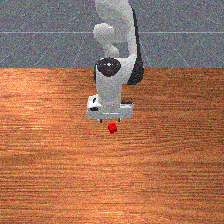

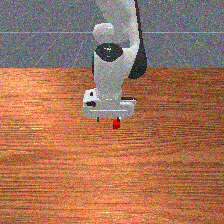

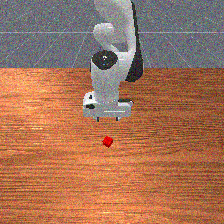

In [ ]:
#@title 6 Display ALL videos saved across all tasks (from the 4 task folders)
from IPython.display import Video, display, HTML, Image as IPImage
from pathlib import Path
import os

def gather_task_videos(task_ids: List[str], *, root: str) -> Dict[str, List[str]]:
    videos_by_task = {}
    for task_id in task_ids:
        task_folder = Path(root) / task_id
        videos = sorted([str(p) for p in task_folder.rglob("*.mp4")])
        videos_by_task[task_id] = videos
    return videos_by_task

task_ids = [TASK_MAP[k]["task_id"] for k in TASKS_TO_RUN]
videos_by_task = gather_task_videos(task_ids, root=EPISODES_ROOT)

total = sum(len(v) for v in videos_by_task.values())
print("Total videos:", total)

for task_id, vids in videos_by_task.items():
    print(f"\n## {task_id} ({len(vids)} videos)")
    if not vids:
        continue

    for i, vp in enumerate(vids):
        # Cerchiamo l'immagine png corrispondente nella stessa cartella.
        # Assunzione: video 0.mp4 -> view_trial_0.png se l'ordine è rispettato
        # In alternativa, cerchiamo semplicemente "view_trial_{i}.png" nella cartella padre
        parent = Path(vp).parent

        # ManiSkill salva i video come 0.mp4, 1.mp4. Estraiamo l'indice dal nome file
        try:
            vid_idx = int(Path(vp).stem) # "0" -> 0
            img_name = f"view_trial_{vid_idx}.png"
            img_path = parent / img_name
        except:
            img_path = None

        display(HTML(f"<div style='font-weight:600; margin-top:20px; border-top:1px solid #444; padding-top:10px;'>Trial Video: {vp}</div>"))

        # Display Static Debug Image
        if img_path and img_path.exists():
            display(HTML(f"<div style='font-size:0.9em; color:#888; margin-bottom:4px;'>📷 Robot View (First Frame with Noise/Occlusion):</div>"))
            display(IPImage(filename=str(img_path), width=256))
        else:
            display(HTML("<i>No debug image found for this trial</i>"))

        # Display Video
        display(Video(vp, embed=True, width=512))

In [ ]:
#!rm -rf /content/lerobot/episodes/*